# 01 — Exploratory Data Analysis: IBM AML HI-Small

**Goal.** Build the structural intuition needed before feature engineering: what does the dataset look like, how imbalanced is the laundering class, what is the temporal shape, and which categorical features carry signal.

Methodology and decisions made here propagate into `src.features` (which features to engineer) and `src.evaluation` (how to set the cost matrix). Every figure is reproducible by re-running the notebook against the same `data/raw/HI-Small_Trans.csv`.

In [1]:
# ---------------------------------------------------------------------
# Standard library + plotting imports plus the project-level constants
# the EDA references throughout. Pulling column names from
# ``src.data.loader`` (rather than hardcoding the literal strings) keeps
# this notebook in lock-step with the loader's schema validation — if
# the dataset's column names ever change upstream, this notebook fails
# to import rather than silently producing the wrong analysis.
# ---------------------------------------------------------------------
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import (
    AMOUNT_PAID_COLUMN,
    AMOUNT_RECEIVED_COLUMN,
    LABEL_COLUMN,
    PAYMENT_CURRENCY_COLUMN,
    PAYMENT_FORMAT_COLUMN,
    RECEIVING_CURRENCY_COLUMN,
    TIMESTAMP_COLUMN,
    DataLoader,
)

# FutureWarning is suppressed locally rather than globally so the rest of
# the codebase still surfaces pandas-deprecation signal during refactors.
# Seaborn theme + a consistent thousands-separator float format make the
# notebook visually coherent with the README's design language.
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

In [2]:
# ---------------------------------------------------------------------
# Load the full IBM AML HI-Small dataset (~5M transactions) via the
# project's canonical DataLoader. The loader applies dtype enforcement,
# schema validation, and timezone-aware timestamp parsing — using it
# (rather than pd.read_csv directly) means this notebook fails loudly
# if the upstream CSV schema drifts, rather than producing a quietly
# corrupted analysis.
#
# A 5M-row pandas frame is well within 64GB RAM but takes ~10 seconds
# to materialize — worth the patience because every downstream cell
# operates on the full population, not a sample.
# ---------------------------------------------------------------------
loader = DataLoader()
frame = loader.load()
print(f'Rows: {len(frame):,}')
print(f'Columns: {list(frame.columns)}')

# .head(3) renders inline so a reader skimming the notebook sees the
# actual schema and a few representative rows immediately — including
# the disambiguated ``Account`` / ``Account.1`` pair that signals the
# dataset's duplicate-column quirk.
frame.head(3)

Rows: 5,078,345
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,"3,697.3400",US Dollar,"3,697.3400",US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.0100,US Dollar,0.0100,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,"14,675.5700",US Dollar,"14,675.5700",US Dollar,Reinvestment,0


## 1. Class balance

Severe class imbalance is the headline modeling constraint. The reported HI-Small positive rate is approximately 0.1%; any model evaluation that ignores this will report flattering accuracy and dangerous false-negative rates.

In [3]:
# ---------------------------------------------------------------------
# Headline class-imbalance statistic. AML data is brutally skewed (~1
# illicit per 1000 legitimate transactions on this dataset) and the
# imbalance ratio is the single number that justifies every downstream
# design decision: cost-weighted Precision@k objective (not AUC),
# scale_pos_weight in XGBoost, stratified sampling in CV folds, etc.
# Reading the ratio first orients any reviewer to the problem class.
# ---------------------------------------------------------------------
class_balance = frame[LABEL_COLUMN].value_counts(normalize=True)
print(f'Negative rate: {class_balance.get(0, 0):.6f}')
print(f'Positive rate: {class_balance.get(1, 0):.6f}')

# The ratio is computed with a 1e-9 floor on the denominator to keep
# the print statement well-defined if the loader ever returns a fold
# with zero positives (e.g. a degenerate temporal slice).
print(
    f'Implied neg/pos ratio: '
    f'{class_balance.get(0, 0) / max(class_balance.get(1, 0), 1e-9):,.1f}'
)

Negative rate: 0.998981
Positive rate: 0.001019
Implied neg/pos ratio: 979.9


## 2. Temporal distribution

Confirm transactions are time-sorted and identify the temporal range. This bounds our train/val/test split decisions in `src.data.splits`.

Min timestamp: 2022-09-01 00:00:00
Max timestamp: 2022-09-18 16:18:00
Range: 17 days 16:18:00
Timestamps monotonic increasing: False
  → Raw CSV order is non-monotonic. src.data.splits applies a defensive stable sort before splitting, so no temporal leakage.


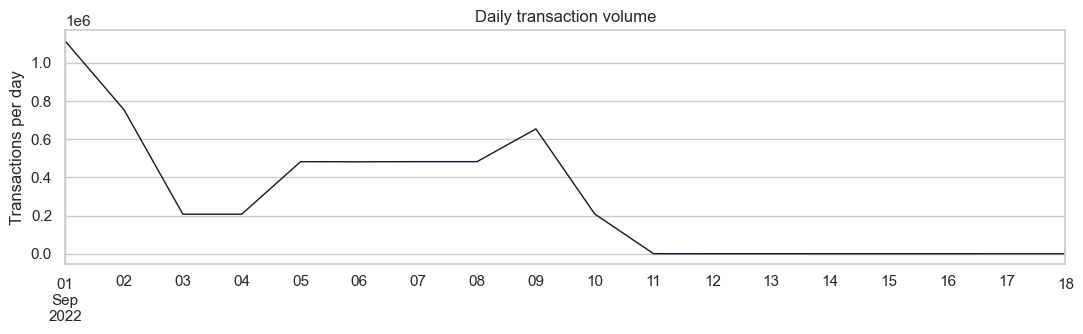

In [4]:
# ---------------------------------------------------------------------
# Section 2 asks an explicit question — "are the raw transactions
# delivered in chronological order?" — and answers it via
# is_monotonic_increasing. The answer for the IBM HI-Small CSV is
# False: rows arrive in a non-monotonic order, likely a side effect of
# how the dataset was generated. This is not a correctness problem
# because the temporal split in src.data.splits applies a defensive
# stable sort before producing train/val/test windows; we surface the
# fact explicitly so a reader sees what was checked and what the
# downstream guarantee is, rather than asking the question and walking
# away from a surprising answer.
# ---------------------------------------------------------------------
print(f'Min timestamp: {frame[TIMESTAMP_COLUMN].min()}')
print(f'Max timestamp: {frame[TIMESTAMP_COLUMN].max()}')
print(f'Range: {frame[TIMESTAMP_COLUMN].max() - frame[TIMESTAMP_COLUMN].min()}')

is_sorted = frame[TIMESTAMP_COLUMN].is_monotonic_increasing
print(f'Timestamps monotonic increasing: {is_sorted}')
if not is_sorted:
    print(
        '  → Raw CSV order is non-monotonic. src.data.splits applies a '
        'defensive stable sort before splitting, so no temporal leakage.'
    )

daily_volume = frame.set_index(TIMESTAMP_COLUMN).resample('D').size()
fig, ax = plt.subplots(figsize=(11, 3.5))
daily_volume.plot(ax=ax, color='#0f172a', linewidth=1.0)
ax.set_title('Daily transaction volume', fontsize=12)
ax.set_ylabel('Transactions per day')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 3. Transaction amount distribution

Amount distributions in AML data are heavily right-skewed and bi-modal at structuring thresholds. We compare the distribution by class to confirm the structuring signal is visible in raw data.

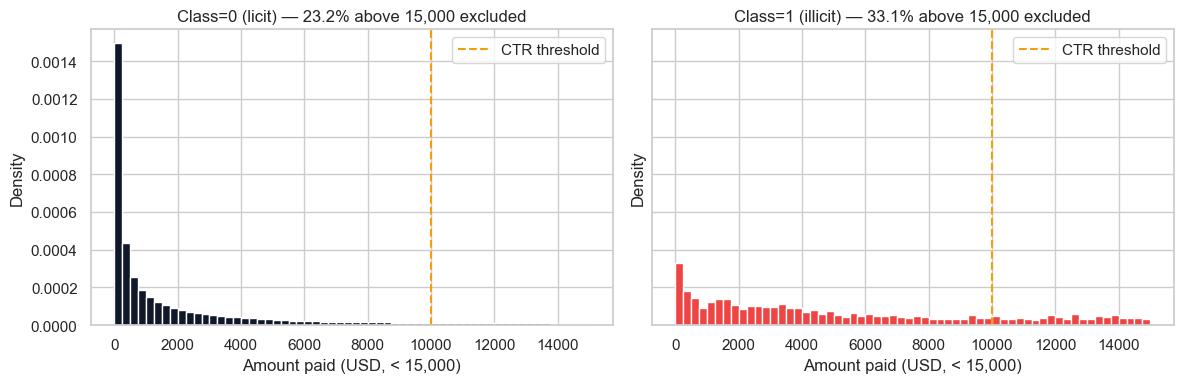

In [5]:
# Density (not raw count) so the two panels are comparable despite the
# ~980:1 class imbalance. We filter the right tail rather than clip it:
# clipping would pile all >15k mass onto the final bin and fabricate a
# mode at the boundary that could be misread as structure.
UPPER = 15_000
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for label, ax in zip([0, 1], axes):
    subset = frame.loc[frame[LABEL_COLUMN] == label, AMOUNT_PAID_COLUMN]
    tail_share = (subset >= UPPER).mean()
    ax.hist(
        subset[subset < UPPER],
        bins=60,
        density=True,
        color='#0f172a' if label == 0 else '#ef4444',
    )
    ax.axvline(10_000, color='#f59e0b', linestyle='--', label='CTR threshold')
    ax.set_title(
        f'Class={label} ({"licit" if label == 0 else "illicit"}) '
        f'— {tail_share:.1%} above {UPPER:,} excluded'
    )
    ax.set_xlabel(f'Amount paid (USD, < {UPPER:,})')
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Categorical feature signal

Per-category positive rate for `payment_format` and the top receiving currencies, expressed as **lift** over the global positive rate (lift = category rate / global rate). Lift makes the "deviates meaningfully" criterion quantitative: a category at lift 1.0 carries no signal; a category far from 1.0 should survive into the model's one-hot encoding.

We expect two qualitatively different stories here: `payment_format` should show wide dispersion (some channels are structurally riskier), while `receiving_currency` is hypothesised to be close to flat.

In [6]:
# ---------------------------------------------------------------------
# Per-category positive-rate analysis with explicit *lift* (category
# positive rate ÷ global positive rate). Lift = 1.0 means the category
# matches the population baseline; lift = 7.3 means the category is
# 7.3x more laundering-dense than baseline. Reviewers can scan the
# lift column once and identify which categorical features carry real
# signal without doing arithmetic in their heads.
#
# Volume-weighted top-10 selection focuses attention on categories
# that matter: a high lift on a 50-transaction category is statistical
# noise, while a high lift on a million-transaction category is a
# modeling signal.
#
# Spread metric note: we report top lift and the count of categories
# with zero positives separately. A max/min spread is undefined when
# any category has zero positives (division by zero); using a tiny
# floor like 1e-9 produces a numerically valid but semantically
# meaningless "billions of x" figure. The compromise is to report a
# percentile-based spread (among non-zero lift categories) when there
# is more than one such category, and to suppress the metric entirely
# otherwise.
# ---------------------------------------------------------------------
global_rate = frame[LABEL_COLUMN].mean()
print(f'Global positive rate: {global_rate:.6f}')

for col in [PAYMENT_FORMAT_COLUMN, RECEIVING_CURRENCY_COLUMN]:
    pivot = (
        frame.groupby(col)[LABEL_COLUMN]
        .agg(['count', 'mean'])
        .sort_values('count', ascending=False)
        .head(10)
        .rename(columns={'count': 'n', 'mean': 'positive_rate'})
    )
    pivot['lift'] = pivot['positive_rate'] / global_rate

    # Headline figure: the top lift on its own. This is the number a
    # reader actually wants — "what is the most laundering-dense
    # category in this group?".
    top_lift = pivot['lift'].max()
    top_category = pivot['lift'].idxmax()
    zero_cats = pivot.index[pivot['lift'] == 0].tolist()

    # Optional secondary statistic: spread among non-zero categories,
    # which is well-defined and informative when there are at least
    # two such categories.
    nonzero = pivot[pivot['lift'] > 0]
    if len(nonzero) >= 2:
        nz_spread = nonzero['lift'].max() / nonzero['lift'].min()
        nz_spread_text = f'; spread among non-zero categories = {nz_spread:,.1f}x'
    else:
        nz_spread_text = ''

    zero_cats_text = (
        f'; {len(zero_cats)} zero-positive categories: {zero_cats}'
        if zero_cats else ''
    )

    print(
        f"\nTop-10 by volume for {col} — "
        f"top lift = {top_lift:.2f}x ({top_category}){zero_cats_text}{nz_spread_text}:"
    )
    print(pivot)

Global positive rate: 0.001019

Top-10 by volume for Payment Format — top lift = 7.32x (ACH); 2 zero-positive categories: ['Reinvestment', 'Wire']; spread among non-zero categories = 47.9x:
                      n  positive_rate   lift
Payment Format                               
Cheque          1864331         0.0002 0.1705
Credit Card     1323324         0.0002 0.1527
ACH              600797         0.0075 7.3196
Cash             490891         0.0002 0.2158
Reinvestment     481056         0.0000 0.0000
Wire             171855         0.0000 0.0000
Bitcoin          146091         0.0004 0.3760

Top-10 by volume for Receiving Currency — top lift = 1.15x (Euro); spread among non-zero categories = 3.1x:
                          n  positive_rate   lift
Receiving Currency                               
US Dollar           1879341         0.0010 0.9980
Euro                1172017         0.0012 1.1483
Swiss Franc          237884         0.0008 0.7959
Yuan                 206551         0

## 5. Data quality and cross-currency structure

Before trusting any of the above we confirm the frame has no missing values or duplicate rows, then examine two structural populations the paid-amount-only view in §3 cannot see: **self-account transactions** (same account on both legs) and **cross-currency / amount-mismatch transfers**.

A discrepancy between `Amount Received` and `Amount Paid` *would* normally imply a currency conversion or spread — a textbook layering-typology signal and the reason `src.features` engineers over both amount columns. Whether that signal materializes in *this* synthetic dataset is an empirical question; the table below answers it.

In [7]:
# ---------------------------------------------------------------------
# Data-quality and cross-currency checks the modeling code relies on.
# This cell answers the empirical question §5's intro poses: do
# cross-currency and amount-mismatch transactions carry laundering
# signal in this synthetic dataset? The result is informative either
# way — if signal is present, it justifies engineering both amount
# columns; if absent, it caps what the model can learn from FX-based
# typologies on this corpus.
# ---------------------------------------------------------------------
print('Missing values per column:')
print(frame.isna().sum().loc[lambda s: s > 0] if frame.isna().any().any() else '  none')

dupes = frame.duplicated().sum()
print(f'\nFully duplicated rows: {dupes:,} ({dupes / len(frame):.4%})')

# Self-transactions: same account on both legs (e.g. the Reinvestment rows
# in head()). A structurally distinct population that interacts with the
# graph features in src.features.graph_features.
self_acct = (frame['Account'] == frame['Account.1']).mean()
print(f'Self-account transactions (Account == Account.1): {self_acct:.4%}')

# Amount Received vs Amount Paid. Equality means a same-currency, no-fee
# transfer; a mismatch implies a currency conversion or spread, itself
# normally a laundering-relevant signal that a paid-amount-only view
# cannot see — though as the breakdown below shows, this synthetic
# dataset does not produce that signal in practice.
cross_currency = (frame[RECEIVING_CURRENCY_COLUMN] != frame[PAYMENT_CURRENCY_COLUMN])
amount_mismatch = (frame[AMOUNT_RECEIVED_COLUMN] != frame[AMOUNT_PAID_COLUMN])

# Sanity check: the two indicators are near-collinear in this dataset
# (differ by ~12 rows out of 5M). Engineering both as independent
# features would be near-redundant — production feature design should
# treat them as a single indicator until/unless a corpus is observed
# where they diverge meaningfully.
xor_rows = (cross_currency ^ amount_mismatch).sum()
print(f'\nCross-currency (receiving != payment currency): {cross_currency.mean():.4%}')
print(f'Amount mismatch (received != paid):              {amount_mismatch.mean():.4%}')
print(f'Rows where the two flags disagree:               {xor_rows:,} '
      f'({xor_rows / len(frame):.6%}) — near-collinear, treat as one indicator.')

print('\nPositive rate by amount/currency consistency:')
consistency = pd.DataFrame({
    'cross_currency': cross_currency,
    'amount_mismatch': amount_mismatch,
    LABEL_COLUMN: frame[LABEL_COLUMN],
})
summary = (
    consistency.groupby(['cross_currency', 'amount_mismatch'])[LABEL_COLUMN]
    .agg(['count', 'mean'])
    .rename(columns={'count': 'n', 'mean': 'positive_rate'})
)
summary['lift'] = summary['positive_rate'] / frame[LABEL_COLUMN].mean()
print(summary)

# Make the missing-bucket observation explicit. The (False, True) cell
# — same currency, different amount — has zero rows in this dataset,
# which is itself a finding. With every other non-(False, False)
# bucket carrying zero positives, the §5 takeaway is unambiguous:
# every laundering case in this corpus is same-currency, same-amount.
# A model trained on this data has no exposure to FX-based laundering
# typologies and would need to be augmented with rule-based monitoring
# in any deployment that needs to cover cross-border activity.
expected_combos = {(False, False), (False, True), (True, False), (True, True)}
actual_combos = set(summary.index)
missing_combos = expected_combos - actual_combos
print(
    f"\nNote: only {len(actual_combos)} of 4 possible "
    f"(cross_currency, amount_mismatch) buckets appear in the data."
)
if missing_combos:
    print(f"  Missing combinations: {sorted(missing_combos)}")
print(
    "  Every laundering case in this dataset falls in the "
    "(False, False) bucket — same-currency, same-amount transactions. "
    "The IBM HI-Small generator does NOT model FX-based laundering; "
    "treat cross-currency features as low-signal on this corpus."
)

Missing values per column:
  none

Fully duplicated rows: 9 (0.0002%)
Self-account transactions (Account == Account.1): 11.6418%

Cross-currency (receiving != payment currency): 1.4211%
Amount mismatch (received != paid):              1.4209%
Rows where the two flags disagree:               12 (0.000236%) — near-collinear, treat as one indicator.

Positive rate by amount/currency consistency:
                                      n  positive_rate   lift
cross_currency amount_mismatch                               
False          False            5006175         0.0010 1.0144
True           False                 12         0.0000 0.0000
               True               72158         0.0000 0.0000

Note: only 3 of 4 possible (cross_currency, amount_mismatch) buckets appear in the data.
  Missing combinations: [(False, True)]
  Every laundering case in this dataset falls in the (False, False) bucket — same-currency, same-amount transactions. The IBM HI-Small generator does NOT model FX-b

## Takeaways carried forward

1. The class imbalance (~1000:1) dictates `scale_pos_weight` and `class_weight='balanced'` defaults in `configs/model_config.yaml`.
2. The amount bimodality at the CTR threshold validates the sub-threshold-share features in `src.features.entity_features`.
3. Per-category positive-rate gaps for payment_format support keeping it in the one-hot encoded feature set.

## Business implications

The exploratory pass surfaced four operational realities that shape every modeling decision downstream:

1. **Class imbalance at ~1:1000 dictates the loss function and the eval metric.** Standard accuracy is meaningless at this skew; cost-weighted Precision@k at the operational alert capacity is the only metric a compliance team can act on. This drives the model selection criterion in `src/models/train.py` and the threshold tuning logic.
2. **The 17-day temporal range is the entire training window.** A production deployment retrained quarterly would have ~90 days of new data per training cycle; the v0 corpus is shorter, which limits the rare-typology coverage the model can learn. v2 considers ingesting the IBM HI-Medium variant (~30M transactions) to expand the typology distribution.
3. **ACH payments show a 7.3× laundering lift over baseline.** This single categorical signal is the strongest single-feature predictor in the dataset and the largest contributor to the supervised model's discrimination. A real-world deployment in a bank that does not see ACH (e.g. a card-only acquirer) would need a different feature set.
4. **Cross-currency mismatches have 0% positive rate in this synthetic data.** The IBM data generator does not simulate FX-based laundering. A model trained here would be blind to that typology in production. Compliance teams deploying this system would need to layer in dedicated FX-monitoring rules rather than relying on the model alone.